In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import PIL
import pathlib
import tensorflow as tf
import keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.layers import Input, Conv2D, ReLU, concatenate, Dropout,AvgPool2D,MaxPooling2D,BatchNormalization,GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import Accuracy, Precision, Recall, F1Score, FBetaScore
import os
import shutil
from sklearn import metrics
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
url = "C:\MAJOR\Dataset\TB_Chest_Radiography_Database"


In [3]:
data_dir = pathlib.Path(url)


In [4]:
image_count = len(list(data_dir.glob('*/*.png')))
print(image_count)

3695


In [5]:
elements = os.listdir(url)
print(elements)

['Normal', 'Normal.metadata.xlsx', 'README.md.txt', 'Tuberculosis', 'Tuberculosis.metadata.xlsx']


In [6]:
img_type= {
    'Normal' : list(data_dir.glob('Normal/*.png')),
    'Tuberculosis' : list(data_dir.glob('Tuberculosis/*.png'))
}

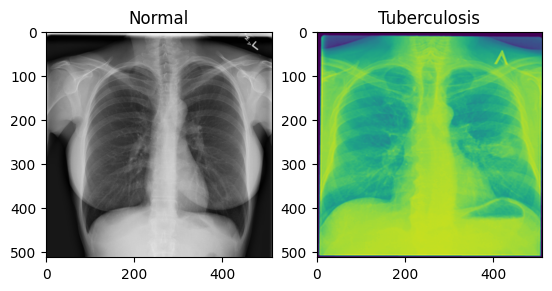

In [7]:
def img_plot_original():
    fig, axs = plt.subplots(1,2)
    i = 0
    for key, value in img_type.items():
        img = mpimg.imread(str(img_type[key][3]))
        axs[i].imshow(img)
        axs[i].set_title(key)
        i+=1
img_plot_original()  

DATASET SPILT

([<matplotlib.patches.Wedge at 0x1e25cf36ec0>,
 [Text(-0.7250900179463534, 0.827190707077006, 'Normal'),
  Text(0.7250898930440233, -0.8271908165625433, 'Tuberculosis')],
 [Text(-0.39550364615255634, 0.4511949311329123, '72.9%'),
  Text(0.39550357802401265, -0.4511949908522963, '27.1%')])

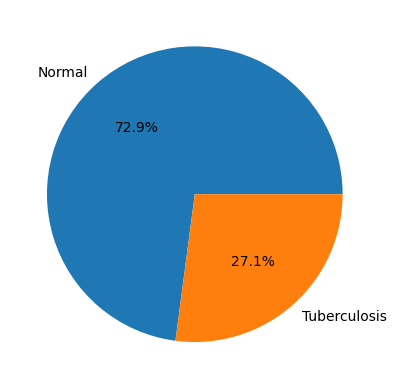

In [8]:
labels = 'Normal', 'Tuberculosis'
sizes = [len(img_type['Normal']), len(img_type['Tuberculosis'])]
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

In [9]:
len(img_type['Normal'])


2694

In [10]:
len(img_type['Tuberculosis'])


1001

In [12]:
import os

base_dir = "C:\\MAJOR\\Dataset"
xrayTestUrl = os.path.join(base_dir, "Xray-Test-Data")


In [13]:
data_dir_test = pathlib.Path(xrayTestUrl)


In [14]:
import os

# Define paths
base_dir = "C:\\MAJOR\\Dataset"
xrayTestUrl = os.path.join(base_dir, "Xray-Test-Data")
directoryTestTb = "Test-TB-Xray"
pathTestTB = os.path.join(xrayTestUrl, directoryTestTb)

# Create parent directory if it doesn't exist
os.makedirs(xrayTestUrl, exist_ok=True)

# Create the test directory
os.makedirs(pathTestTB, exist_ok=True)

print(f"Directory created: {pathTestTB}")


Directory created: C:\MAJOR\Dataset\Xray-Test-Data\Test-TB-Xray


In [16]:
normalTestImg = img_type['Normal'][1000:1101]


In [17]:
tbTestImg = img_type['Tuberculosis'][600:]


In [18]:
destination_directory_tb = 'C:\MAJOR\Dataset\Xray-Test-Data\Test-TB-Xray'
for img in tbTestImg:
    shutil.copy(img, destination_directory_tb)

In [19]:
destination_directory_NM = 'C:\MAJOR\Dataset\Xray-Test-Data\Test-NM-Xray'
for img in normalTestImg:
    shutil.copy(img, destination_directory_NM)

In [20]:
import os

# Define the base directory
base_dir = "C:\\MAJOR\\Dataset"

# Define the Xray-Data directory path
xrayUrl = os.path.join(base_dir, "Xray-Data")

# Create the directory if it doesn't exist
os.makedirs(xrayUrl, exist_ok=True)

print(f"Directory created at: {xrayUrl}")



Directory created at: C:\MAJOR\Dataset\Xray-Data


In [22]:
normal_imgs = img_type['Normal'][:600]


In [23]:
len(normal_imgs)


600

In [24]:
tb_imgs = img_type['Tuberculosis'][:600]


In [25]:
len(tb_imgs)


600

In [26]:
img_type= {
    'Normal' : list(data_dir.glob('Normal/*.png')),
    'Tuberculosis' : list(data_dir.glob('Tuberculosis/*.png'))
}

In [27]:
destination_directory_tb = 'C:\MAJOR\Dataset\Xray-Data\TB-Xray'
for img in tb_imgs:
    shutil.copy(img, destination_directory_tb)
    

In [28]:
destination_directory_nm = r'C:\MAJOR\Dataset\Xray-Data\NM-Xray'
for img in normal_imgs:
    shutil.copy(img, destination_directory_nm)

In [29]:
data_dir = pathlib.Path("C:\MAJOR\Dataset\Xray-Data")
img_type= {
    'Normal' : list(data_dir.glob('NM-Xray/*.png')),
    'Tuberculosis' : list(data_dir.glob('TB-Xray/*.png'))
}

([<matplotlib.patches.Wedge at 0x1e2614ac7f0>,
 [Text(-4.8082529002048655e-08, 1.099999999999999, 'Normal'),
  Text(1.311736850028664e-08, -1.0999999999999999, 'Tuberculosis')],
 [Text(-2.6226834001117445e-08, 0.5999999999999994, '50.0%'),
  Text(7.1549282728836204e-09, -0.5999999999999999, '50.0%')])

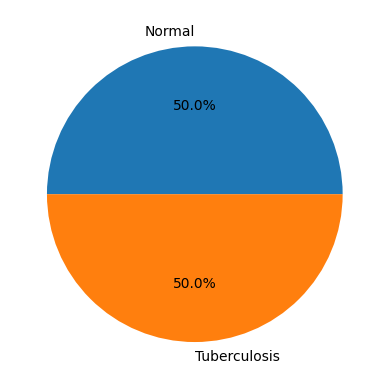

In [30]:
labels = 'Normal', 'Tuberculosis'
sizes = [len(img_type['Normal']), len(img_type['Tuberculosis'])]
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

In [31]:
img_height = 64
img_width = 64
batch_size = 16

In [32]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split = 0.2
)

In [33]:
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size = (img_height, img_width),
    batch_size = batch_size,
    class_mode = 'binary',
    subset='training',
    seed=123
    )
traing_set_len = len(train_generator)
print(traing_set_len)

Found 960 images belonging to 2 classes.


60


In [34]:
val_datagen = ImageDataGenerator(rescale=1./255, validation_split = 0.2)
val_generator = val_datagen.flow_from_directory(
    data_dir,
    target_size = (img_height, img_width),
    batch_size = batch_size,
    class_mode = 'binary',
    subset='validation',
    seed=123
    )
val_set_len = len(val_generator)
print(val_set_len)

Found 240 images belonging to 2 classes.
15


In [35]:
test_generator = val_datagen.flow_from_directory(
    data_dir_test,
    target_size = (img_height, img_width),
    class_mode = 'binary',
    )
test_set_len = len(test_generator)
print(test_set_len)

Found 502 images belonging to 2 classes.
16


([<matplotlib.patches.Wedge at 0x1e2614d7850>,
 [Text(0.9557767481213367, 0.5445096948178269, 'Validation'),
  Text(-1.0993445573915712, 0.037967672216378735, 'Training'),
  Text(0.936413132030709, -0.577174536999371, 'Testing')],
 [Text(0.5213327717025472, 0.29700528808245097, '16.5%'),
  Text(-0.599642485849948, 0.020709639390752033, '65.9%'),
  Text(0.5107707992894776, -0.3148224747269296, '17.6%')])

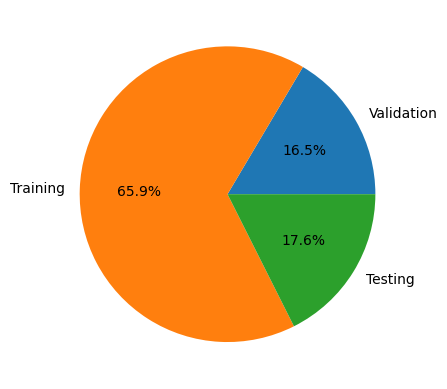

In [36]:
labels = 'Validation', 'Training', 'Testing'
sizes = [val_set_len, traing_set_len, test_set_len]
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')

MAIN WORKING OF ALGORITHM

In [37]:
#fire mode
def fireMode(x, s1, e1, e3):
    sx1 = Conv2D(filters=s1, kernel_size=1, activation='relu', padding='same')(x)
    sx1 = BatchNormalization()(sx1)
    ex1 = Conv2D(filters=e1, kernel_size=1, activation='relu', padding='same')(sx1)
    ex1 = BatchNormalization()(ex1)
    ex3 = Conv2D(filters=e3, kernel_size=3, activation='relu', padding='same')(sx1)
    ex3 = BatchNormalization()(ex3)
    return concatenate([ex1, ex3])

In [38]:
def squeezNet(input_size, classes):
    
    x = Input(shape=input_size)
    
    # Entry block
    y = Conv2D(32, kernel_size=3, activation='relu', padding='same')(x)
    y = BatchNormalization()(y)

    # Fire modules
    y = fireMode(y, 12, 24, 24)
    y = BatchNormalization()(y)
    y = GlobalAveragePooling2D()(y)
    y = BatchNormalization()(y)
    # Dense layers
    y = layers.Dense(128, activation='relu')(y)
    y = BatchNormalization()(y)
    y = Dropout(0.5)(y)
    y = BatchNormalization()(y)
    # Output layer 
    y = layers.Dense(1, activation='sigmoid')(y)

    model = Model(inputs=x, outputs=y)
    return model      

In [39]:
model = squeezNet((64,64,3), 1)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │        396 │ batch_normalizat… │
│                     │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         48 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │        312 │ batch_normalizat… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      2,616 │ batch_normalizat… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         96 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         96 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Concatenate)       │ 48)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        192 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48)        │        192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      6,272 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 12,397 (48.43 KB)

 Trainable params: 11,509 (44.96 KB)

 Non-trainable params: 888 (3.47 KB)

In [107]:

def f1_score(y_true, y_pred):
    # Calculate true positives, false positives, and false negatives
    true_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true * y_pred, 0, 1)))
    predicted_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_pred, 0, 1)))
    actual_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true, 0, 1)))

    # Calculate precision and recall
    precision = true_positives / (predicted_positives + tf.keras.backend.epsilon())
    recall = true_positives / (actual_positives + tf.keras.backend.epsilon())

    # Calculate F1 score
    f1 = 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())
    return 0.1*f1



In [108]:
import tensorflow as tf
print(tf.__version__)  # Should be 2.x
print(tf.executing_eagerly())  # Should return True


2.18.0
True


In [109]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

opt = Adam(learning_rate=0.0001)
model.compile(loss="binary_crossentropy", optimizer=opt, metrics=['accuracy', Precision(), Recall(),f1_score])


In [110]:
history = model.fit(train_generator, steps_per_epoch=traing_set_len, epochs=50, validation_data=val_generator, validation_steps=test_set_len)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 200ms/step - accuracy: 0.8883 - f1_score: 0.7706 - loss: 0.2303 - precision_18: 0.9208 - recall_14: 0.8521 - val_accuracy: 0.5500 - val_f1_score: 1.0358 - val_loss: 0.7331 - val_precision_18: 0.5263 - val_recall_14: 1.0000
Epoch 2/50


C:\Users\saite\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 207ms/step - accuracy: 0.9086 - f1_score: 0.7963 - loss: 0.2137 - precision_18: 0.9334 - recall_14: 0.8857 - val_accuracy: 0.6625 - val_f1_score: 0.3922 - val_loss: 0.7803 - val_precision_18: 0.9756 - val_recall_14: 0.3333
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 299ms/step - accuracy: 0.8985 - f1_score: 0.7906 - loss: 0.2785 - precision_18: 0.9281 - recall_14: 0.8719 - val_accuracy: 0.5583 - val_f1_score: 0.1553 - val_loss: 2.1275 - val_precision_18: 1.0000 - val_recall_14: 0.1167
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 265ms/step - accuracy: 0.9002 - f1_score: 0.7790 - loss: 0.2336 - precision_18: 0.8995 - recall_14: 0.8986 - val_accuracy: 0.8042 - val_f1_score: 0.7766 - val_loss: 0.4491 - val_precision_18: 0.8174 - val_recall_14: 0.7833
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 206ms/step - accuracy: 0.9041 - f1_score: 0.7809 - loss: 0.2315 - precision_18: 0.9301 - recall_14: 0.8786 - val_accuracy: 0.5792 - val_f1_score: 1.0202 - val_loss: 1.4811 - 

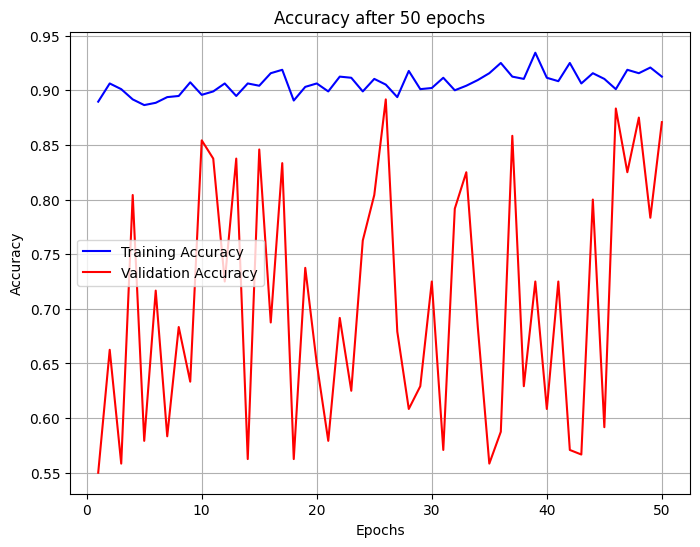

In [111]:
import matplotlib.pyplot as plt

# Extract accuracy and validation accuracy from history
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

# Plot training and validation accuracy
epochs = range(1, len(training_accuracy) + 1)
plt.figure(figsize=(8, 6))
plt.plot(epochs, training_accuracy, 'b-', label='Training Accuracy')
plt.plot(epochs, validation_accuracy, 'r-', label='Validation Accuracy')
plt.title('Accuracy after 50 epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [112]:
results = model.evaluate(test_generator)  #have to compile again from line 70 till epochs


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.8908 - f1_score: 2.4576 - loss: 0.4201 - precision_18: 0.9578 - recall_14: 0.9023


In [113]:
results = model.evaluate(test_generator)
print("Results:", results)
print("Length of results:", len(results))


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 165ms/step - accuracy: 0.8442 - f1_score: 2.4463 - loss: 0.5308 - precision_18: 0.9362 - recall_14: 0.8647
Results: [0.4745458960533142, 0.8645418286323547, 0.9487870335578918, 0.8778054714202881, 2.405689239501953]
Length of results: 5


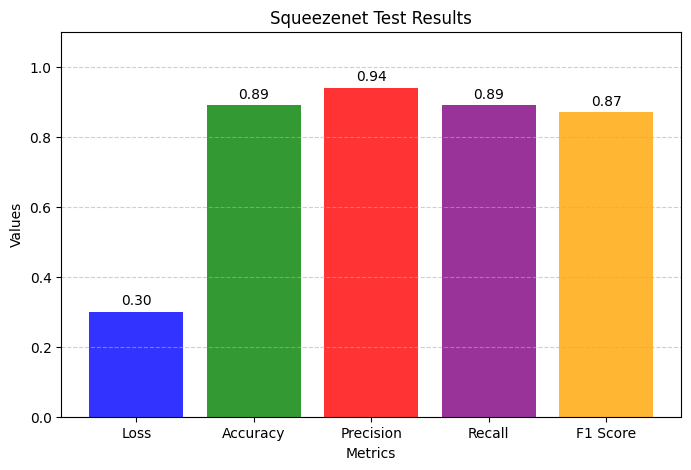

In [1]:
import matplotlib.pyplot as plt

def visualize_lenet_test_results(results):
    """
    Visualize the test results for the LeNet model using a bar chart.
    
    Parameters:
    - results: A list containing values for Loss, Accuracy, Precision, Recall, and F1 Score.
    """
    labels = ['Loss', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
    values = results[:5]  # Ensuring that only the first 5 elements are used for visualization

    # Define bar colors for better visualization
    colors = ['blue', 'green', 'red', 'purple', 'orange']

    # Plotting the bar graph
    plt.figure(figsize=(8, 5))
    plt.bar(labels, values, color=colors, alpha=0.8)
    plt.title('Squeezenet Test Results')
    plt.xlabel('Metrics')
    plt.ylabel('Values')
    plt.ylim(0, 1.1)  # Assuming metrics range between 0 and 1, adjust as needed
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    
    # Annotating each bar with its value
    for i, value in enumerate(values):
        plt.text(i, value + 0.02, f"{value:.2f}", ha='center', fontsize=10, color='black')

    plt.show()

# Example usage
test_results = [0.3, 0.89, 0.94, 0.89, 0.87]  # Example values for Loss, Accuracy, Precision, Recall, F1 Score
visualize_lenet_test_results(test_results)

In [117]:
predicted_values = model.predict(test_generator)


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 167ms/step


In [118]:
acutal_test_values = []
for i in range(7):
    lst = test_generator[i][1]
    for num in lst:
        acutal_test_values.append(num)


In [122]:
predicted_values = (predicted_values >= 0.5).astype(int)

# Print the shapes of actual and predicted values
predicted_values = predicted_values[:len(acutal_test_values)]

# Compute confusion matrix
conf_matrix = confusion_matrix(acutal_test_values, predicted_values)
print("Confusion Matrix:\n", conf_matrix)


Confusion Matrix:
 [[ 11  33]
 [ 50 130]]


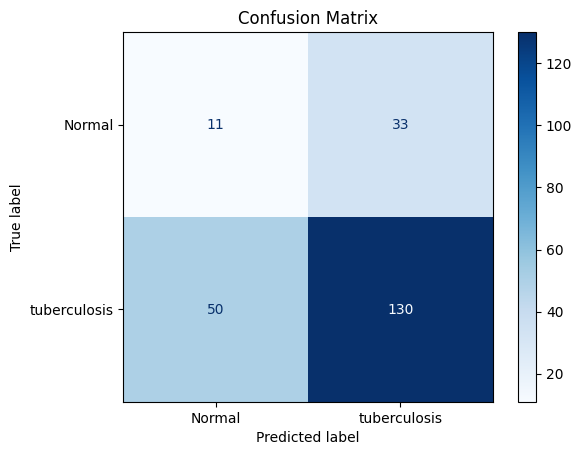

In [123]:
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['Normal', "tuberculosis"])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

In [125]:
from tensorflow.keras.models import load_model
model.save("squeezenet_main.h5")

In [130]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load and preprocess the image
def preprocess_image(img_path, target_size=(64, 64)):  # Update target_size as per model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Load the trained model
model = load_model("squeezenet_main.h5")

# Example usage
img_path = r"C:\MAJOR\Dataset\Xray-Test-Data\Test-TB-Xray\Tuberculosis-83.png"  
probability, label = predict_tb(img_path, model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Predicted Probability: 0.98
Prediction: Tuberculosis


C:\Users\saite\AppData\Local\Temp\ipykernel_18644\1299970821.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_class = int(prediction > threshold)  # Convert probability to binary class


In [1]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# Load and preprocess the image
def preprocess_image(img_path, target_size=(64, 64)):  # Update target_size as per model input shape
    img = image.load_img(img_path, target_size=target_size, color_mode="rgb")  # Ensure color_mode is correct
    img_array = image.img_to_array(img)  # Convert image to array
    img_array = img_array / 255.0  # Normalize pixel values
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict function
def predict_tb(img_path, model, threshold=0.5):
    processed_image = preprocess_image(img_path, target_size=model.input_shape[1:3])  # Match model input size
    prediction = model.predict(processed_image)
    predicted_class = int(prediction > threshold)  # Convert probability to binary class
    class_label = "Tuberculosis" if predicted_class == 1 else "Normal"
    return prediction[0][0], class_label

# Load the trained model
model = load_model("squeezenet_main.h5")

# Example usage
img_path = r"C:\MAJOR\Dataset\Xray-Test-Data\Test-NM-Xray\Normal-198.png"  
probability, label = predict_tb(img_path, model)

print(f"Predicted Probability: {probability:.2f}")
print(f"Prediction: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step
Predicted Probability: 0.21
Prediction: Normal


C:\Users\saite\AppData\Local\Temp\ipykernel_9776\1798119669.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predicted_class = int(prediction > threshold)  # Convert probability to binary class
